# Customer Churn Prediction

### Phase 1 - Load and Understand Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/churn_dataset.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

### Phase 2 - Data Quality Checks

Check missing values

In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Check Duplicates

In [9]:
df.duplicated().sum()

np.int64(0)

Check Target Distribution :

In [10]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [11]:
df["Churn"].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

### Phase 3 - Data Cleaning


In [13]:
# Data Type
df["TotalCharges"].dtype

dtype('O')

In [ ]:
# Converting Object to Float
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"].dtype

dtype('float64')

In [16]:
# Checking Nulls again
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [18]:
# Drop missing rows :
df = df.dropna()

### Phase 4 - EDA

Visulaization 1 - Churn Distribution

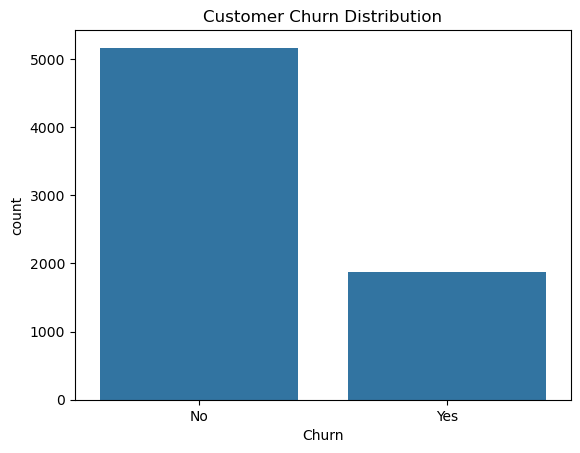

In [23]:
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

Visualization 2 - Contract vs Churn

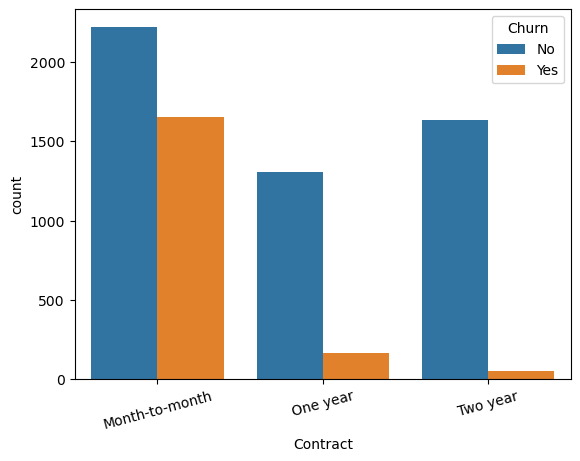

In [24]:
sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.xticks(rotation=15)
plt.show()

Visualization 3 - Tenure vs Churn

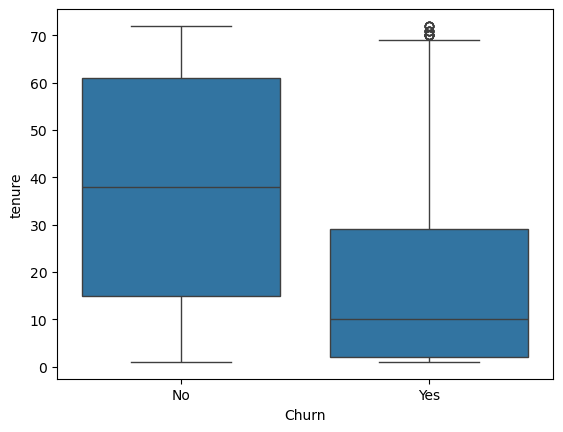

In [26]:
sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)

plt.show()

Visualization 4 - Monthly Charges vs Churn

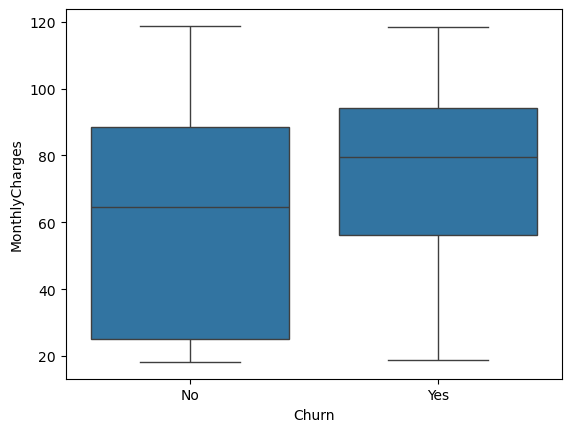

In [27]:
sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.show()

Visualization 5 - Internet Service vs Churn

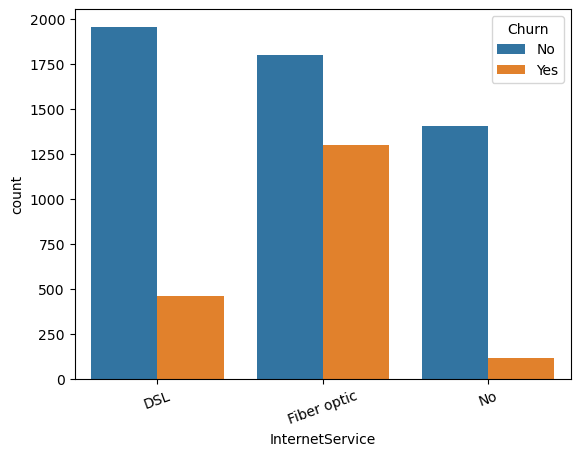

In [31]:
sns.countplot(
    x="InternetService",
    hue="Churn",
    data=df
)

plt.xticks(rotation=20)
plt.show()

### Phase 5 - Business Insights

##### Key Findings

1. Month-to-month customers show the highest churn.

2. Customers with lower tenure churn more frequently.

3. Customers paying higher monthly charges
   are more likely to leave.

4. Fiber optic users show elevated churn rates.

5. Long-term contracts improve retention.

### Phase 6 - Feature Engineering

In [32]:
# Removing CustomerID
df = df.drop("customerID", axis=1)

In [33]:
# Convert Target
df["Churn"] = df["Churn"].map({
    "No":0,
    "Yes":1
})

In [34]:
# Encode Categories
df = pd.get_dummies(
    df,
    drop_first=True
)

### Phase 7 - Machine Learning

In [36]:
# Check the Dataset
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


Step 1 - Create Features and Target

In [40]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

Step 2 - Train-Test split

In [38]:
from sklearn.model_selection import train_test_split

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Meaning - 80% Training, 20% Testing

Step 3 - Build Logistic Regression

In [43]:
from sklearn.linear_model import LogisticRegression

In [47]:
lr = LogisticRegression(max_iter=5000)

lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


Step 4 - Predictions

In [ ]:
y_pred = lr.predict(X_test)

# Model now predicts:

# Customer 1 → churn
# Customer 2 → no churn
# Customer 3 → churn

Step 5 - Evaluation

In [49]:
from sklearn.metrics import classification_report

In [50]:
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



Step 6 - Confusion Matrix

In [51]:
from sklearn.metrics import confusion_matrix

In [52]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[916, 117],
       [181, 193]])

Step 7 - Visualize Confusion Matrix

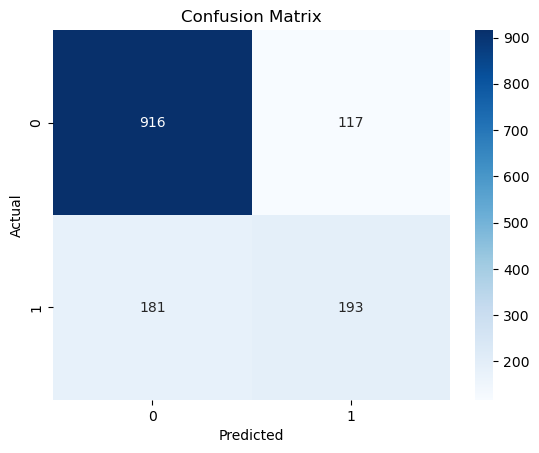

In [57]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Step 8 - Random Forest

In [58]:
from sklearn.ensemble import RandomForestClassifier

In [59]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Step 9 - Predictions

In [62]:
rf_pred = rf.predict(X_test)

Step 10 - Evaluation

In [63]:
print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.48      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



Step 11 - Feature Importance

In [64]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
3,TotalCharges,0.193409
2,MonthlyCharges,0.169758
1,tenure,0.167572
10,InternetService_Fiber optic,0.039999
28,PaymentMethod_Electronic check,0.035016
13,OnlineSecurity_Yes,0.028905
25,Contract_Two year,0.028618
4,gender_Male,0.026971
19,TechSupport_Yes,0.025829
26,PaperlessBilling_Yes,0.025044


Plot Top 10 Features

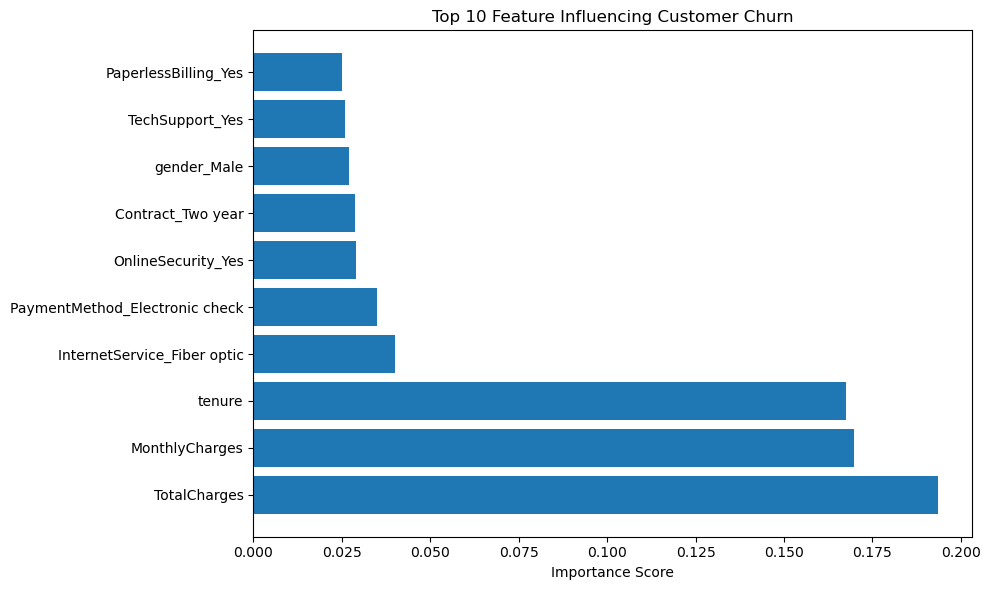

In [66]:
top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10['Feature'], top10['Importance'])
plt.title("Top 10 Feature Influencing Customer Churn")
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

Step 12 - ROC AUC Score

In [ ]:
from sklearn.metrics import roc_auc_score

rf_probs = rf.predict_proba(X_test)[:,1]

roc_auc_score(y_test, rf_probs)
# Strong Value

0.8160205206785698

Step 13 - Confusion Matrix Visualzation

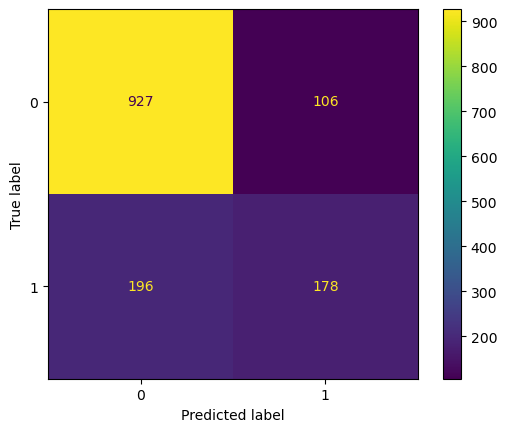

In [69]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.show()